8-Page Web Adjacency Matrix:
     A  B  C  D  E  F  G  H
A   [0. 0. 1. 1. 0. 0. 0. 0.]
B   [1. 0. 0. 0. 0. 0. 0. 0.]
C   [1. 1. 0. 0. 0. 0. 0. 0.]
D   [0. 1. 1. 0. 0. 0. 0. 0.]
E   [0. 0. 0. 1. 0. 0. 0. 0.]
F   [0. 0. 0. 0. 1. 0. 1. 0.]
G   [0. 0. 0. 0. 0. 1. 0. 0.]
H   [0. 0. 0. 1. 0. 0. 0. 0.]
Page A -> ['B', 'C'])
Page B -> ['C', 'D'])
Page C -> ['A', 'D'])
Page D -> ['A', 'E', 'H'])
Page E -> ['F'])
Page F -> ['G'])
Page G -> ['F'])
Page H -> None (dangling_node)

Dangling Nodes:['H'] - no outgoing links

Damping factor d = 0.85 applied successfully
Converged in 75 with Final error = 9.60e-07


Page | PageRank Score | Percentage
------------------------------------------
  A  |    0.084104    |   8.41%
  B  |    0.059595    |   5.96%
  C  |    0.084924    |   8.49%
  D  |    0.085272    |   8.53%
  E  |    0.048012    |   4.80%
  F  |    0.306071    |   30.61%
  G  |    0.284011    |   28.40%
  H  |    0.048012    |   4.80%
------------------------------------------
Sum: 1.000000 (

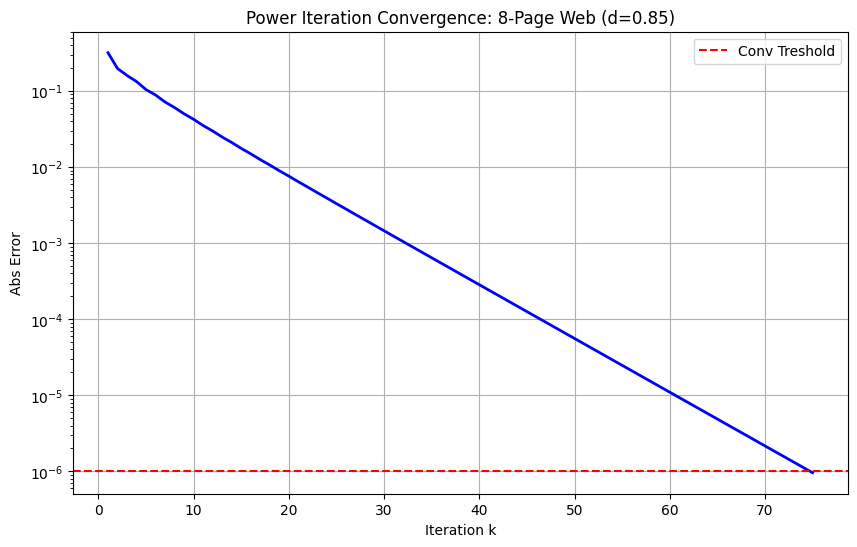

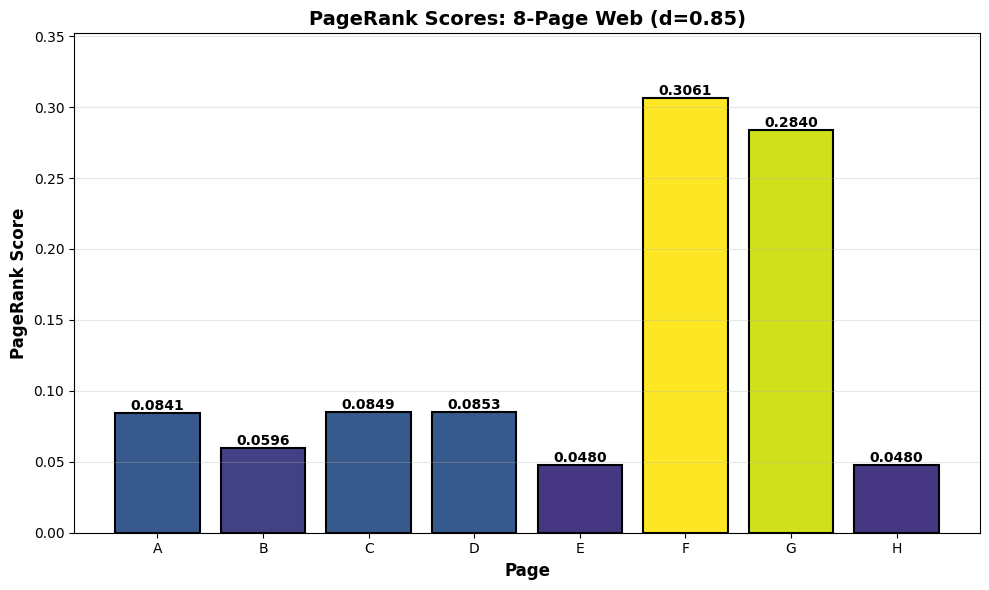

Validation Passed

  Rank 1: Page F  -  0.306071  (30.61%)
  Rank 2: Page G  -  0.284011  (28.40%)
  Rank 3: Page D  -  0.085272  (8.53%)
  Rank 4: Page C  -  0.084924  (8.49%)
  Rank 5: Page A  -  0.084104  (8.41%)
  Rank 6: Page B  -  0.059595  (5.96%)
  Rank 7: Page E  -  0.048012  (4.80%)
  Rank 8: Page H  -  0.048012  (4.80%)


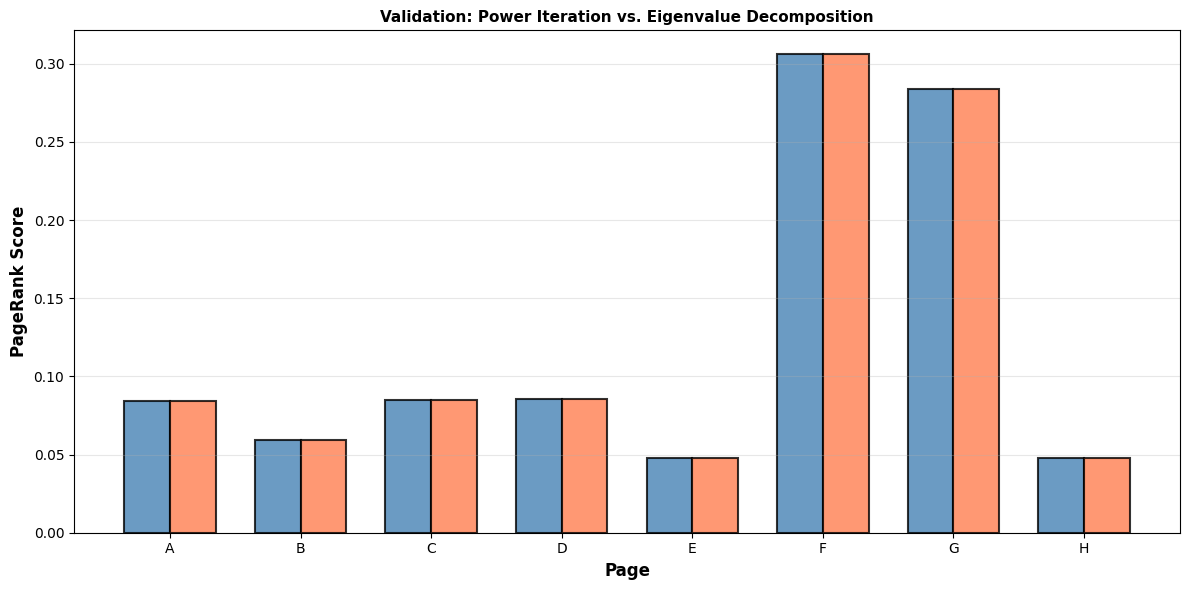

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pagerank_implementation import * 

# Section 4: Analysis & Experiments

In this section we will analyze the behaviour of the PageRank algorithm, validate the applied mathematical concepts, explore the actual aplication and test the robustness of the algorithm. To do so, we will perform four experiments as follows: 

1. Initial Vector Independence (Mathematical Foundation) - During this experiment we will demonstrate the strength of the PageRank algorithm - regardless of how the surfer starts its journey within the web, the pages score remains steady. We will test this by applying 3 different initial vectors, run Power Iteration from each starting point and verify that in all 3 cases result in the same final vector.
2.  Personalized PageRank (Practical Application): in this experiment we are going to simulate personalized behaviour of the web surferer. We will consider that the surfer is biased and jumps towards specific pages. The question we will try to answer is how this personalized behavoir changes the page ranking to favor user interest? We will touch base the topic for applying user history and personalization for generating a page score.
3.  Network Connectivity (Structural Analysis): in this experiment we will investigate how sensitive is the network structure to changes and more specifically to removing links. Generally, the web structure determines the importance of the pages and their RangeRank score. We will show how the scores change and compare which pages are most affected when bridges between links are removed.
4.  Link Manipulation (vulnerability Testing)- in this last subsection we will demonstrate how adding artificial links in the web can boost a pages' ranking. This is the so called 'search engine optimization" attack and shows how vulnerable is PageRank to strategic and intentinal link manipulation.        

## Initial Vector Independence
This experiment aims to validate the main feature of the PageRank algorithm - the steady-state distribution of the scores is unique regardless of the starting point (initial probability distribution). [Refer to Perron-Frobenius Theorem]. We will execute the experiment by running the Power Iteration from 5 differnt starting points:

1. Uniform Distribution - all pages equally likely (already applied in the implementation phase Section 3)
2. Concentrated on Page A - all probability concentrated on one page.
3. 3 Random distributions - sampled from Dirichlet distribution [Refer to Dirichlet distribution why we choose it]

   




## Personalized PageRank

Currenly, for calculating the PageRank scores we apply the uniform distribution -  a random surfer jumps from pages to pages, so each webpage has "equal" probability to be visited. However, in reality, the surfer will visit the page that "favors" and the distribution is actually biased. We will represent this biased behaviour by modifiyng the transition matrix formula and including a personalization vector. We will test three types of "teleportations":

1. Standard ("uniform teleportation")
2. Personalized for Page A (always visit page A)
3. Personalized for Spider Trap F+G (favor those pages)

We will start with the standard PageRank computation where the surfer can jump to any page with equal probability - uniform distribution (1/n each). This was already done in the previous section, so we will show just the transformation matrix with applied damping effect and the resulted PageRank scores from applying the power iteration approach.

In [9]:
m_web
m_prime_web #transition matrix
r_web  #pagerank values
history_web #convergence history

print("\nPage | PageRank Score | Percentage")
print("-" * 42)
for i, (label, score) in enumerate(zip(page_labels, r_web)):
    print(f"  {label}  |    {score:.6f}    |   {score*100:.2f}%")
print("-" * 42)
print(f"Sum: {r_web.sum():.6f} (should be 1.0)")


Page | PageRank Score | Percentage
------------------------------------------
  A  |    0.084104    |   8.41%
  B  |    0.059595    |   5.96%
  C  |    0.084924    |   8.49%
  D  |    0.085272    |   8.53%
  E  |    0.048012    |   4.80%
  F  |    0.306071    |   30.61%
  G  |    0.284011    |   28.40%
  H  |    0.048012    |   4.80%
------------------------------------------
Sum: 1.000000 (should be 1.0)


The original formula we applied for calculating the transition matrix was: $M' = d \cdot M + \frac{1 - d}{n} \cdot E$ 

Now we are going to apply the modified formula [reference here]: $M' = d \cdot M + (1 - d) \cdot v_{personalized} \cdot 1^T$;

where  $v_{personalized}$ is the biased vector.

Now we are going to add the bias effect where the surfer prefers to jumps towars page A by applying a personalized initial vector where the probability of visiting page A is increased to 1.0 (100%) -> $[1,0,0 \dots ,0]$


In [42]:
d = 0.85 #damping_factor

transition_matrix = m_web #original transition matrix - 
n = transition_matrix.shape[0] #erturns the number of pages

v_pageA = np.zeros(n) # personalized vector
v_pageA[0] = 1 # all probability goes to page A

personalization_matrix = np.zeros((n,n))
personalization_matrix[0,:] = np.ones(n) #all probability assigned to page A in the personalization matrix

In [45]:
personalization_matrix = np.outer(v_pageA,np.ones(n)) # we can use np.outer for more complicated personalized matrix - returning the outer product of two vectors - Matrix (n x n)

In [65]:
m_prime_pageA = d * transition_matrix + (1-d) * personalization_matrix
column_sums_pageA = m_prime_pageA.sum(axis = 0) 

print(f"Transition Matrix with biased behaviour\n")
print (f"{m_prime_pageA}\n")
print(f"Sum of Columns: {column_sums_pageA} (should be 1.0 for all columns)")

Transition Matrix with biased behaviour

[[0.15   0.15   0.575  0.4333 0.15   0.15   0.15   0.2563]
 [0.425  0.     0.     0.     0.     0.     0.     0.1062]
 [0.425  0.425  0.     0.     0.     0.     0.     0.1062]
 [0.     0.425  0.425  0.     0.     0.     0.     0.1062]
 [0.     0.     0.     0.2833 0.     0.     0.     0.1062]
 [0.     0.     0.     0.     0.85   0.     0.85   0.1062]
 [0.     0.     0.     0.     0.     0.85   0.     0.1062]
 [0.     0.     0.     0.2833 0.     0.     0.     0.1062]]

Sum of Columns: [1. 1. 1. 1. 1. 1. 1. 1.] (should be 1.0 for all columns)


In [69]:
#test with damping effect
transition_matrix = m_prime_web
n = transition_matrix.shape[0] #erturns the number of pages

v_pageA = np.zeros(n) # personalized vector
v_pageA[0] = 1 # all probability goes to page A

personalization_matrix = np.zeros((n,n))
personalization_matrix[0,:] = np.ones(n) #all probability assigned to page A in the personalization matrix

m_prime_pageA = d * transition_matrix + (1-d) * personalization_matrix
column_sums_pageA = m_prime_pageA.sum(axis = 0) 

print(f"Transition Matrix with biased behaviour\n")
print (f"{m_prime_pageA}\n")
print(f"Sum of Columns: {column_sums_pageA} (should be 1.0 for all columns)")

Transition Matrix with biased behaviour

[[0.1659 0.1659 0.5272 0.4068 0.1659 0.1659 0.1659 0.2563]
 [0.3772 0.0159 0.0159 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.3772 0.3772 0.0159 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.3772 0.3772 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.2568 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.0159 0.7384 0.0159 0.7384 0.1062]
 [0.0159 0.0159 0.0159 0.0159 0.0159 0.7384 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.2568 0.0159 0.0159 0.0159 0.1062]]

Sum of Columns: [1. 1. 1. 1. 1. 1. 1. 1.] (should be 1.0 for all columns)


In [68]:
#Definition of the function

def add_personalized_damping (transition_matrix, personalization_vector, damping_factor = 0.85):
    n = transition_matrix.shape[0] #erturns the number of pages
    d = damping_factor

    personalization_matrix = np.outer(personalization_vector,np.ones(n)) #v_personalized * 1^T
    m_prime = d * transition_matrix + (1 - d) * personalization_matrix # apply modified scoring formula

    return m_prime

In [72]:
m_prime_pageA = add_personalized_damping(m_prime_web,v_pageA)

In [73]:
print(f"Transition Matrix with biased behaviour\n")
print (f"{m_prime_test_pageA}\n")
print(f"Sum of Columns: {m_prime_test_pageA.sum(axis=0)} (should be 1.0 for all columns)")

Transition Matrix with biased behaviour

[[0.1659 0.1659 0.5272 0.4068 0.1659 0.1659 0.1659 0.2563]
 [0.3772 0.0159 0.0159 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.3772 0.3772 0.0159 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.3772 0.3772 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.2568 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.0159 0.7384 0.0159 0.7384 0.1062]
 [0.0159 0.0159 0.0159 0.0159 0.0159 0.7384 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.2568 0.0159 0.0159 0.0159 0.1062]]

Sum of Columns: [1. 1. 1. 1. 1. 1. 1. 1.] (should be 1.0 for all columns)


In [82]:
#Compare the Power Iteration and Eigenvector Score with the new transition matrix

r_pageA, history_pageA = pagerank_power_iteration(m_prime_pageA,1e-6) # apply the personalized vector 

r_web, history_web # PI Standard page scores

r_eig, error #Standard Eigenvector page scores

print("\nPage | Standard | Biased A  | Change_pi | Change_ev  ")
print("-"*60)
for i, label in enumerate(page_labels):
    change_pi = r_pageA[i] - r_web[i]
    change_ev = r_pageA[i] - r_eig[i]
    print(f"  {label}  | {r_eig[i]:.6f} | {r_pageA[i]:.6f} | {change_pi:+.6f} | {change_ev:+.6f}")

Converged in 39 with Final error = 7.26e-07


Page | Standard | Biased A  | Change_pi | Change_ev  
------------------------------------------------------------
  A  | 0.084104 | 0.253037 | +0.168933 | +0.168933
  B  | 0.059595 | 0.111692 | +0.052097 | +0.052097
  C  | 0.084924 | 0.152041 | +0.067118 | +0.067118
  D  | 0.085272 | 0.115556 | +0.030285 | +0.030285
  E  | 0.048012 | 0.048113 | +0.000101 | +0.000101
  F  | 0.306071 | 0.145814 | -0.160257 | -0.160257
  G  | 0.284011 | 0.125633 | -0.158378 | -0.158378
  H  | 0.048012 | 0.048113 | +0.000101 | +0.000101


From the above comparison we can see that the biased behavior of the surfer actually changes significantly the PageRank score of pageA. While, initialy the page was mostly never visited, now its score significantly improved due to the application of the surfer preferences.   

In [ ]:
#Test with Spider Trap Personalization

## Network Connectivity

PageRank depends heavily on the web structure. Adjusting the links can isolate parts of the graph or affects "authority propagation". With this experiment hereby we will remove several critical links and observe the impact. Based on our current web structure we will do the following:    

1. Remove the link D → E: This will remove the bridge from main cluster to the spider trap path.
2. Remove the link C → A: This will createa a cycle in main cluster within the graph.
3. Remove the link E → F: Remove the entry point to spider trap.

## Link Manipulation

We will investigate how strong is the PageRank algorithm against manipulation "attacks". Websites' Owners can try to artificially improve their scores creating fake links pointing to their site, getting links from pages with high scores or use other linking schemes.

In this experiment we will simulate an attacker who tries to boost Page # score (low score) through strategic link addition: 

1. Add link from Page # (page with the highest score) to Page #
2. Add links from pages #, # and # (multiple high score pages) to page #
3. Same as point 2, but test lower lower damping factor.   
